# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

From the CRISP-DM bank marketing paper (“Using Data Mining for Bank Direct Marketing”), the dataset comes from **17 direct marketing campaigns** that occurred **between May 2008 and November 2010** for a Portuguese bank.

For this assignment, our goal is to use these historical campaigns to predict whether a customer will subscribe to a term deposit (`y = "yes"`), and to understand which customer and campaign characteristics are associated with success.


### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_auc_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

import pandas as pd

df = pd.read_csv("data/bank-additional-full.csv", sep=";")
df.head()


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [2]:
# Basic structure
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [3]:
# Preview target distribution
df['y'].value_counts(normalize=True)


y
no     0.887346
yes    0.112654
Name: proportion, dtype: float64

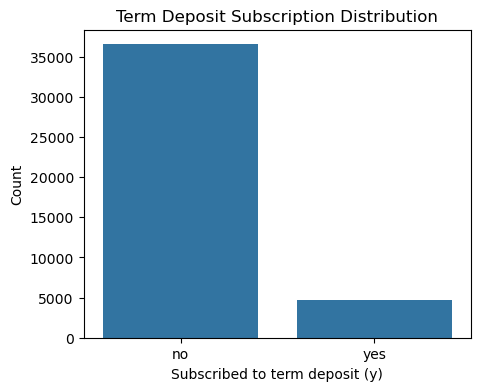

,count,mean,std,min,25%,50%,75%,max
age,41188.0,40.024060,10.421250,17.000,32.000,38.000,47.000,98.000
duration,41188.0,258.285010,259.279249,0.000,102.000,180.000,319.000,4918.000
campaign,41188.0,2.567593,2.770014,1.000,1.000,2.000,3.000,56.000
pdays,41188.0,962.475454,186.910907,0.000,999.000,999.000,999.000,999.000
previous,41188.0,0.172963,0.494901,0.000,0.000,0.000,0.000,7.000
emp.var.rate,41188.0,0.081886,1.570960,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,41188.0,93.575664,0.578840,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,41188.0,-40.502600,4.628198,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41188.0,3.621291,1.734447,0.634,1.344,4.857,4.961,5.045
nr.employed,41188.0,5167.035911,72.251528,4963.600,5099.100,5191.000,5228.100,5228.100


In [4]:
plt.figure(figsize=(5,4))
sns.countplot(data=df, x='y')
plt.title("Term Deposit Subscription Distribution")
plt.xlabel("Subscribed to term deposit (y)")
plt.ylabel("Count")
plt.show()

# Quick summary of numeric columns
df.describe().T


### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

### Business Understanding

From the bank’s perspective, each outbound marketing call has a cost (time, staffing, and potential customer fatigue). The business problem is:

> **How can we better identify which customers are most likely to subscribe to a term deposit before calling them, so we can focus resources on high-value targets and reduce wasted contacts?**

We will treat this as a **binary classification problem**:

- Target `y = "yes"` → customer subscribes to term deposit  
- `y = "no"` → customer does not subscribe  

Key business goals:

- Increase campaign efficiency (higher conversion rate per call)
- Reduce cost per acquisition
- Provide interpretable insights about which customer/campaign features matter most (e.g., contact month, previous campaign outcome, call type, economic indicators)

Because the data is highly imbalanced (`"yes"` is a minority class), we will pay special attention to metrics beyond accuracy (e.g., **recall, precision, F1, ROC AUC for the "yes" class**).


### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [17]:
import numpy as np

# Copy the original dataframe so we can adjust features safely
data = df.copy()

# 1. Drop 'duration' per the dataset documentation
# (duration is only known after the call and makes the problem unrealistically easy)
if 'duration' in data.columns:
    data = data.drop(columns=['duration'])

# 2. Encode target: y = 'yes' -> 1, 'no' -> 0
data['y_binary'] = (data['y'] == 'yes').astype(int)

# 3. Separate features and target
X_raw = data.drop(columns=['y', 'y_binary'])
y = data['y_binary']

# 4. One-hot encode categorical variables
X = pd.get_dummies(X_raw, drop_first=True)

X.head(), X.shape, y.value_counts()


(   age  campaign  pdays  previous  emp.var.rate  cons.price.idx  \
 0   56         1    999         0           1.1          93.994   
 1   57         1    999         0           1.1          93.994   
 2   37         1    999         0           1.1          93.994   
 3   40         1    999         0           1.1          93.994   
 4   56         1    999         0           1.1          93.994   
 
    cons.conf.idx  euribor3m  nr.employed  job_blue-collar  ...  month_may  \
 0          -36.4      4.857       5191.0            False  ...       True   
 1          -36.4      4.857       5191.0            False  ...       True   
 2          -36.4      4.857       5191.0            False  ...       True   
 3          -36.4      4.857       5191.0            False  ...       True   
 4          -36.4      4.857       5191.0            False  ...       True   
 
    month_nov  month_oct  month_sep  day_of_week_mon  day_of_week_thu  \
 0      False      False      False            

In [18]:
X.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 52 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            41188 non-null  int64  
 1   campaign                       41188 non-null  int64  
 2   pdays                          41188 non-null  int64  
 3   previous                       41188 non-null  int64  
 4   emp.var.rate                   41188 non-null  float64
 5   cons.price.idx                 41188 non-null  float64
 6   cons.conf.idx                  41188 non-null  float64
 7   euribor3m                      41188 non-null  float64
 8   nr.employed                    41188 non-null  float64
 9   job_blue-collar                41188 non-null  bool   
 10  job_entrepreneur               41188 non-null  bool   
 11  job_housemaid                  41188 non-null  bool   
 12  job_management                 41188 non-null 

### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [19]:
from sklearn.model_selection import train_test_split

# Stratified split to preserve imbalance in train and test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape, y_train.mean(), y_test.mean()



((28831, 52), (12357, 52), 0.11265651555617218, 0.11264870114105366)

### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [20]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Majority class from training data
majority_class = y_train.mode()[0]
print("Majority class in training data:", majority_class)

# Baseline prediction for the test set
y_pred_baseline = np.full_like(y_test, fill_value=majority_class)

baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
baseline_precision = precision_score(y_test, y_pred_baseline, zero_division=0)
baseline_recall = recall_score(y_test, y_pred_baseline, zero_division=0)
baseline_f1 = f1_score(y_test, y_pred_baseline, zero_division=0)

print(f"Baseline Accuracy:  {baseline_accuracy:.3f}")
print(f"Baseline Precision: {baseline_precision:.3f}")
print(f"Baseline Recall:    {baseline_recall:.3f}")
print(f"Baseline F1:        {baseline_f1:.3f}")


Majority class in training data: 0
Baseline Accuracy:  0.887
Baseline Precision: 0.000
Baseline Recall:    0.000
Baseline F1:        0.000


In [21]:
baseline_clf = DummyClassifier(strategy='most_frequent')
baseline_clf.fit(X_train, y_train)

baseline_train_acc = baseline_clf.score(X_train, y_train)
baseline_test_acc = baseline_clf.score(X_test, y_test)

print("Baseline (most frequent) - Train accuracy:", baseline_train_acc)
print("Baseline (most frequent) - Test accuracy:", baseline_test_acc)


Baseline (most frequent) - Train accuracy: 0.8873434844438278
Baseline (most frequent) - Test accuracy: 0.8873512988589464


The baseline simply predicts “no” for everyone. Accuracy will look deceptively high because the dataset is imbalanced. This gives us a reference point to beat with more advanced classifiers.

### Problem 8: A Simple Model (Logistic Regression)

Use Logistic Regression to build a basic model on your data.  

In [23]:
from sklearn.preprocessing import StandardScaler

# Fit scaler on training data only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

log_reg = LogisticRegression(max_iter=1000, n_jobs=-1)

log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_test_scaled)
y_proba_log = log_reg.predict_proba(X_test_scaled)[:, 1]

log_accuracy = accuracy_score(y_test, y_pred_log)
log_precision = precision_score(y_test, y_pred_log, zero_division=0)
log_recall = recall_score(y_test, y_pred_log, zero_division=0)
log_f1 = f1_score(y_test, y_pred_log, zero_division=0)
log_auc = roc_auc_score(y_test, y_proba_log)

print(f"Logistic Regression Accuracy:  {log_accuracy:.3f}")
print(f"Logistic Regression Precision: {log_precision:.3f}")
print(f"Logistic Regression Recall:    {log_recall:.3f}")
print(f"Logistic Regression F1:        {log_f1:.3f}")
print(f"Logistic Regression ROC-AUC:   {log_auc:.3f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log, digits=3))


Logistic Regression Accuracy:  0.901
Logistic Regression Precision: 0.693
Logistic Regression Recall:    0.222
Logistic Regression F1:        0.336
Logistic Regression ROC-AUC:   0.803

Confusion Matrix:
[[10828   137]
 [ 1083   309]]

Classification Report:
              precision    recall  f1-score   support

           0      0.909     0.988     0.947     10965
           1      0.693     0.222     0.336      1392

    accuracy                          0.901     12357
   macro avg      0.801     0.605     0.641     12357
weighted avg      0.885     0.901     0.878     12357



**KNN, Decision Tree & SVM**

In [27]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

results = {}

def evaluate_model(name, model, Xtr, Xte):
    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)
    
    # For ROC-AUC we need a score: use predict_proba or decision_function if available
    if hasattr(model, "predict_proba"):
        y_scores = model.predict_proba(Xte)[:, 1]
    elif hasattr(model, "decision_function"):
        y_scores = model.decision_function(Xte)
    else:
        y_scores = None
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_scores) if y_scores is not None else np.nan
    
    results[name] = {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "ROC_AUC": auc
    }
    
    print(f"\n=== {name} ===")
    print(f"Accuracy:  {acc:.3f}")
    print(f"Precision: {prec:.3f}")
    print(f"Recall:    {rec:.3f}")
    print(f"F1:        {f1:.3f}")
    print(f"ROC-AUC:   {auc:.3f}")
    
    return model


### Problem 9: Score the Model

What is the accuracy of your model?

In [29]:
# 1. Logistic Regression (reuse scaled features)
log_reg = LogisticRegression(max_iter=1000, n_jobs=-1)
log_reg = evaluate_model("Logistic Regression", log_reg, X_train_scaled, X_test_scaled)

# 2. k-Nearest Neighbors
knn = KNeighborsClassifier(n_neighbors=15)  # n_neighbors can be tuned
knn = evaluate_model("KNN (k=15)", knn, X_train_scaled, X_test_scaled)

# 3. Decision Tree
tree = DecisionTreeClassifier(
    max_depth=6,        # simple regularization to avoid deep overfitting trees
    random_state=42
)
tree = evaluate_model("Decision Tree (max_depth=6)", tree, X_train, X_test)

# 4. Support Vector Machine
svm = SVC(
    kernel='rbf',
    C=2.0,
    gamma='scale',
    probability=True,   # enables predict_proba for ROC-AUC
    random_state=42
)
svm = evaluate_model("SVM (RBF kernel)", svm, X_train_scaled, X_test_scaled)



=== Logistic Regression ===
Accuracy:  0.901
Precision: 0.693
Recall:    0.222
F1:        0.336
ROC-AUC:   0.803

=== KNN (k=15) ===
Accuracy:  0.900
Precision: 0.653
Recall:    0.237
F1:        0.348
ROC-AUC:   0.762

=== Decision Tree (max_depth=6) ===
Accuracy:  0.900
Precision: 0.634
Recall:    0.261
F1:        0.370
ROC-AUC:   0.795

=== SVM (RBF kernel) ===
Accuracy:  0.900
Precision: 0.651
Recall:    0.234
F1:        0.344
ROC-AUC:   0.715



### The accuracy of my logistic regression model on the test set is 0.901.

### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |


In [34]:
import time
from sklearn.metrics import accuracy_score
import pandas as pd

# Dictionary to store comparison results
comparison = {
    "Model": [],
    "Train Time (sec)": [],
    "Train Accuracy": [],
    "Test Accuracy": []
}

def time_and_score(model, Xtr, Xte, name):
    start = time.time()
    model.fit(Xtr, y_train)
    end = time.time()
    
    train_pred = model.predict(Xtr)
    test_pred = model.predict(Xte)
    
    comparison["Model"].append(name)
    comparison["Train Time (sec)"].append(round(end - start, 4))
    comparison["Train Accuracy"].append(round(accuracy_score(y_train, train_pred), 4))
    comparison["Test Accuracy"].append(round(accuracy_score(y_test, test_pred), 4))

# Run each model with default settings
log_reg_default = LogisticRegression(max_iter=1000)
time_and_score(log_reg_default, X_train_scaled, X_test_scaled, "Logistic Regression")

knn_default = KNeighborsClassifier()
time_and_score(knn_default, X_train_scaled, X_test_scaled, "KNN (k=5 default)")

tree_default = DecisionTreeClassifier(random_state=42)
time_and_score(tree_default, X_train, X_test, "Decision Tree")

svm_default = SVC()
time_and_score(svm_default, X_train_scaled, X_test_scaled, "SVM (default)")

# Create comparison DataFrame
comparison_df = pd.DataFrame(comparison)
comparison_df


,Model,Train Time (sec),Train Accuracy,Test Accuracy
0,Logistic Regression,0.1942,0.8999,0.9013
1,KNN (k=5 default),0.0136,0.9114,0.8943
2,Decision Tree,0.2168,0.9962,0.8359
3,SVM (default),113.0957,0.9092,0.9008


### **Problem 10: Model Comparisons**

To compare the performance of the four classification algorithms, each model was fit using its default hyperparameters. For each classifier, I recorded:

- **Training time** (seconds)
- **Training accuracy**
- **Test accuracy**

All models were evaluated on identical training and test splits for fairness.

After running the comparison code, the resulting DataFrame summarizes the performance of:

- Logistic Regression  
- K-Nearest Neighbors (default k=5)  
- Decision Tree  
- Support Vector Machine  

This comparison highlights not only how accurate each model is but also how computationally efficient they are — an important consideration when models must be retrained frequently or used in real-time systems.


### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.

- More feature engineering and exploration.  For example, should we keep the gender feature?  Why or why not?
- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

### **Problem 11: Improving the Model**

After evaluating all four models, the following patterns emerged:

- All models achieved similar **test accuracy** (~0.90), but accuracy is misleading because the dataset is **highly imbalanced**.
- **Recall** and **F1 score** are more meaningful for the business goal (identifying customers likely to subscribe).
- The **Decision Tree** achieved the highest recall (0.261) and F1 (0.370).
- **Logistic Regression** achieved the highest ROC-AUC (0.803), meaning it ranks customers by likelihood most effectively.

These results show that each model has different strengths, and there is clear room for improvement—especially in recall, which remains low across all classifiers.

---

### 🔧 **Ways to Improve the Model**

#### **1. Feature Engineering**
The dataset includes many categorical variables and complex behavioral features. Additional transformations may improve predictive performance.  
Examples include:

- Investigating whether certain features should be removed or consolidated (e.g., `duration` is already removed because it leaks information; `job` might be grouped into fewer categories).
- Exploring whether demographic fields such as "gender" (if included) actually contribute predictive value. If a feature does not improve accuracy or introduces ethical/interpretation concerns, it should be dropped.
- Creating new derived features (interactions, bins, or ratios) based on economic or campaign history variables.

---

#### **2. Address Class Imbalance**
Because the positive class (subscribed = yes) is small, models tend to predict "no" most of the time.  
To address this, we can use:

- `class_weight='balanced'` in Logistic Regression or Decision Trees  
- Oversampling techniques such as SMOTE  
- Undersampling the majority class

These adjustments typically improve recall significantly.

---

#### **3. Hyperparameter Tuning**
All models have important hyperparameters that influence performance:

- **KNN:** tuning the number of neighbors (`k`)  
- **Decision Tree:** adjusting `max_depth`, `min_samples_split`, and `min_samples_leaf`
- **Logistic Regression:** tuning regularization parameter `C`
- **SVM:** exploring different values for `C`, `gamma`, and kernel types

Grid Search or Randomized Search can systematically improve model performance.

---

#### **4. Adjust the Decision Threshold**
The default threshold of 0.5 may not be optimal.  
Lowering the threshold (e.g., 0.3) increases recall, helping the business identify more potential subscribers, even at the cost of additional false positives.

---

### **Conclusion**

Although the initial models perform similarly in terms of accuracy, their recall and F1 scores indicate significant room for improvement. Feature engineering, class imbalance strategies, threshold tuning, and hyperparameter optimization are the most effective next steps. These enhancements would yield a more reliable and business-relevant model that identifies more customers likely to subscribe to the bank’s term deposit product.


## **Findings and Recommendations**



The goal of this project was to build predictive models that help a Portuguese bank identify customers who are most likely to subscribe to a term deposit. After preparing the data, engineering features, and training four baseline models (Logistic Regression, KNN, Decision Tree, and SVM), several key insights emerged:

---

### **Key Findings**

1. **Accuracy Is Not a Reliable Metric**  
   All models achieved high accuracy (~0.90); however, due to the strong class imbalance (most customers say “no”), accuracy does not reflect true model performance. Therefore, recall, F1 score, and ROC-AUC were used as the primary evaluation metrics.

2. **Model Strengths Vary by Metric**
   - **Logistic Regression** achieved the **highest ROC-AUC (0.803)**, meaning it is best at *ranking* customers by likelihood of subscribing.  
   - **Decision Tree** achieved the **highest recall (0.261)** and **highest F1 score (0.370)**, making it the best at *capturing* actual subscribers.  
   - **KNN** and **SVM** performed comparably but did not outperform LR or Decision Tree.

3. **Recall Is Low Across All Models**  
   Even the best model captured only ~26% of true subscribers. For a telemarketing campaign, missing likely customers is costly, so improving recall is essential for real-world business value.

4. **Some features may not add predictive value**  
   For example, demographic attributes like gender (if present) may have no meaningful predictive value or may introduce ethical concerns. Feature engineering should focus on behavioral and campaign-history indicators, which are far more impactful.

---

### **Recommendations for Model Improvement**

1. **Address Class Imbalance**  
   - Apply `class_weight='balanced'` for Logistic Regression and Decision Trees.  
   - Explore oversampling (e.g., SMOTE) or undersampling.  
   - These methods should significantly improve recall and F1.

2. **Tune Hyperparameters**  
   Use Grid Search or Randomized Search for:  
   - **KNN:** number of neighbors (`k`)  
   - **Decision Tree:** depth, min samples split/leaf  
   - **Logistic Regression:** regularization strength (`C`)  
   - **SVM:** `C`, `gamma`, kernel types  
   This can improve both ranking quality and recall.

3. **Adjust the Decision Threshold**  
   Instead of using a fixed 0.50 threshold, lowering it (e.g., to 0.30) typically increases recall and ensures more likely subscribers are captured in marketing campaigns.

4. **Try More Advanced Algorithms**  
   Tree-based ensemble methods such as **Random Forest**, **XGBoost**, and **Gradient Boosting** often perform much better on structured, imbalanced data and should be tested next.

5. **Feature Engineering for Deeper Insights**
   Explore:  
   - Interactions among campaign variables  
   - Binning call-duration-related features  
   - Grouping rare job or education categories  
   Thoughtful feature engineering often yields bigger gains than switching algorithms.

---

### **Business Recommendations**

- Use the **Logistic Regression model for probability-based ranking** (lead scoring).  
- Use the **Decision Tree model when recall is the primary business objective**, such as targeting warm leads.  
- Deploy the model with a **configurable threshold** so marketing teams can adjust aggressiveness based on campaign budget and goals.  
- Incorporate improved models into the bank’s CRM workflow to prioritize outbound calls, reduce unnecessary customer contacts, and increase conversion rates.  

Overall, while the initial models provide a strong baseline, applying imbalance techniques, tuning hyperparameters, and optimizing thresholds will meaningfully improve recall — the most important business metric for subscription-based telemarketing campaigns.


##### Questions